In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt

In [19]:
from keras import utils
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from keras.optimizers import Adam

In [20]:
import io
import os
import pickle
import ssl
import subprocess
import sys
import tarfile
import urllib.error
import urllib.request

import numpy as np

CIFAR_DIR = './cifar10_data'
PARQUET = {
    'train': 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/train-00000-of-00001.parquet',
    'test': 'https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/test-00000-of-00001.parquet',
}
TAR_URL = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
MB = 1 << 20


def _open(url):
    try:
        return urllib.request.urlopen(url)
    except (urllib.error.URLError, ssl.SSLError) as err:
        if not isinstance(getattr(err, 'reason', err), ssl.SSLError):
            raise
        print('сертификат не проверился, качаю без проверки')
        return urllib.request.urlopen(url, context=ssl._create_unverified_context())


def _download(url, path, title):
    """Качает файл с показом процентов. Уже скачанный не трогает."""
    if os.path.isfile(path):
        return path

    response = _open(url)
    total = int(response.headers.get('Content-Length') or 0)
    done = shown = 0
    with response, open(path + '.part', 'wb') as out:
        while chunk := response.read(MB):
            out.write(chunk)
            done += len(chunk)
            if not total:
                print(f'\r{title}  {done // MB} МБ', end='', flush=True)
            elif done == total or done - shown >= total // 20:   # шаг 5 процентов
                shown = done
                print(f'\r{title}  {done / total:5.1%}  {done // MB} из {total // MB} МБ', end='', flush=True)
    print()
    os.replace(path + '.part', path)
    return path


def _parquet_tools():
    """Возвращает pyarrow и Pillow, при надобности ставит их."""
    try:
        import pyarrow.parquet as pq
        from PIL import Image
    except ImportError:
        print('ставлю pyarrow и pillow')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow', 'pillow'], check=True)
        import pyarrow.parquet as pq
        from PIL import Image
    return pq, Image


def _split_from_parquet(split, root):
    pq, Image = _parquet_tools()
    path = _download(PARQUET[split], os.path.join(root, f'cifar10_{split}.parquet'), f'CIFAR-10 {split}')
    table = pq.read_table(path)
    images = table.column('img').to_pylist()
    labels = np.array(table.column('label').to_pylist(), dtype='uint8').reshape(-1, 1)
    x = np.stack([np.array(Image.open(io.BytesIO(item['bytes'])).convert('RGB'), dtype=np.uint8)
                  for item in images])
    return x, labels


def _from_tar(root):
    archive = _download(TAR_URL, os.path.join(root, 'cifar-10-python.tar.gz'), 'CIFAR-10')
    batches = os.path.join(root, 'cifar-10-batches-py')
    if not os.path.isdir(batches):
        with tarfile.open(archive) as tar:
            try:
                tar.extractall(root, filter='data')   # на python 3.12 и новее
            except TypeError:
                tar.extractall(root)

    def read(names):
        xs, ys = [], []
        for name in names:
            with open(os.path.join(batches, name), 'rb') as f:
                batch = pickle.load(f, encoding='bytes')
            xs.append(batch[b'data'])
            ys.extend(batch[b'labels'])
        x = np.concatenate(xs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype('uint8')
        return x, np.array(ys, dtype='uint8').reshape(-1, 1)

    return read([f'data_batch_{i}' for i in range(1, 6)]), read(['test_batch'])


def load_cifar10(root=CIFAR_DIR):
    """То же, что keras.datasets.cifar10.load_data(), но с быстрого зеркала."""
    os.makedirs(root, exist_ok=True)
    try:
        return _split_from_parquet('train', root), _split_from_parquet('test', root)
    except (ImportError, subprocess.CalledProcessError):
        print('pyarrow не встал, беру архив с toronto.edu, это дольше')
    except (urllib.error.URLError, TimeoutError, OSError):
        print('зеркало не отвечает, беру архив с toronto.edu, это дольше')
    return _from_tar(root)

In [21]:
(X_train, y_train), (X_test, y_test) = load_cifar10()

CIFAR-10 train  100.0%  114 из 114 МБ
CIFAR-10 test  100.0%  22 из 22 МБ


In [22]:
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (50000, 32, 32, 3)
y_train shape (50000, 1)
X_test shape (10000, 32, 32, 3)
y_test shape (10000, 1)


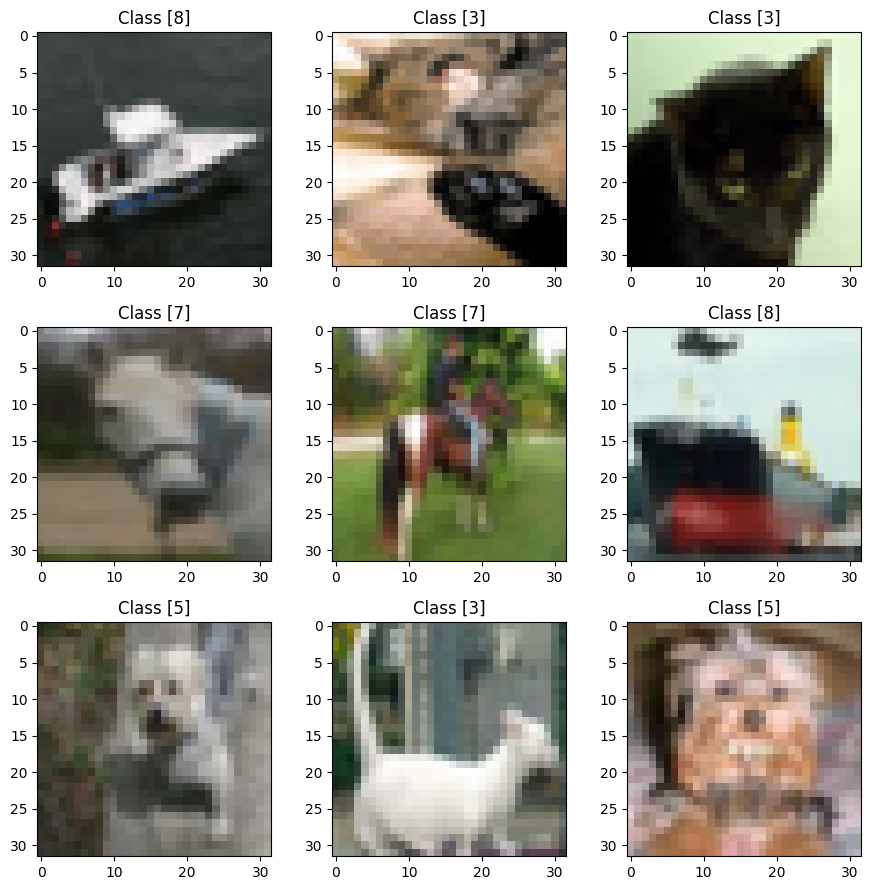

In [23]:
plt.rcParams['figure.figsize'] = (9,9)

for i in range(9):
    plt.subplot(3,3,i+1)
    num = random.randint(0, len(X_train))
    plt.imshow(X_train[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(y_train[num]))

plt.tight_layout()

In [24]:
X_train = X_train.astype('float32') / 255  # конвертируем данные в формат float.
X_test = X_test.astype('float32') / 255    # нормируем каждый пиксель

print("Training matrix shape", X_train.shape)
print("Testing matrix shape", X_test.shape)

Training matrix shape (50000, 32, 32, 3)
Testing matrix shape (10000, 32, 32, 3)


In [25]:
classes = 10
# переводим числа, которые хранятся в "y" в классы, т.е. распределение вероятности
# тогда сеть сможет давать ответ на основе наибольшего из чисел [0, 0.9, 0.1, 0, 0, ..., 0] -> 1
y_train_cat = utils.to_categorical(y_train, classes)
y_test_cat = utils.to_categorical(y_test, classes)

In [26]:
model = Sequential()

In [27]:
# 1 блок(32x32): Conv32 - Batch_norm - Conv32 -  Batch_norm - Max_pooling32 - Dropout
model.add(Input(shape=(32, 32, 3)))                              # форма входа
model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))  # свёрточный слой
model.add(BatchNormalization())                                  # нормализация батча
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 16, 16, 32)

In [28]:
# 2 блок(16x16): Conv64 - Batch_norm - Conv64 -  Batch_norm - Max_pooling64 - Dropout
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 8, 8, 64)

In [29]:
# 3 блок(8x8): Conv128 - Batch_norm - Conv128 -  Batch_norm - Max_pooling128 - Dropout
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 4, 4, 128)

In [30]:
# 4 блок(4x4): Conv256 - Batch_norm - Conv256 -  Batch_norm - Max_pooling256 - Dropout
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.output_shape

(None, 2, 2, 256)

In [31]:
# 5 блок
model.add(Flatten())
print(model.output_shape)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(classes, activation='softmax')) # "результат работы сети"
print(model.output_shape)

(None, 1024)
(None, 10)


In [32]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,706,026 (6.51 MB)

 Trainable params: 1,704,106 (6.50 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [16]:
# Гиперпараметры
epochs = 25
batch_size = 64

# Обучение
history = model.fit(X_train, y_train_cat,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_test, y_test_cat),
                    verbose=1)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.4469 - loss: 1.5581 - val_accuracy: 0.4948 - val_loss: 1.4818
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6275 - loss: 1.0651 - val_accuracy: 0.6692 - val_loss: 0.9466
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6965 - loss: 0.8834 - val_accuracy: 0.6737 - val_loss: 1.0264
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7388 - loss: 0.7658 - val_accuracy: 0.7404 - val_loss: 0.7780
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7658 - loss: 0.6879 - val_accuracy: 0.7495 - val_loss: 0.7725
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7902 - loss: 0.6174 - val_accuracy: 0.7538 - val_loss: 0.7488
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8098 - loss: 0.5611 - val_accuracy: 0.7979 - val_loss: 0.6177
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8217 - loss: 0.5209 - val_acc


Точность на тестовом наборе: 84.04%


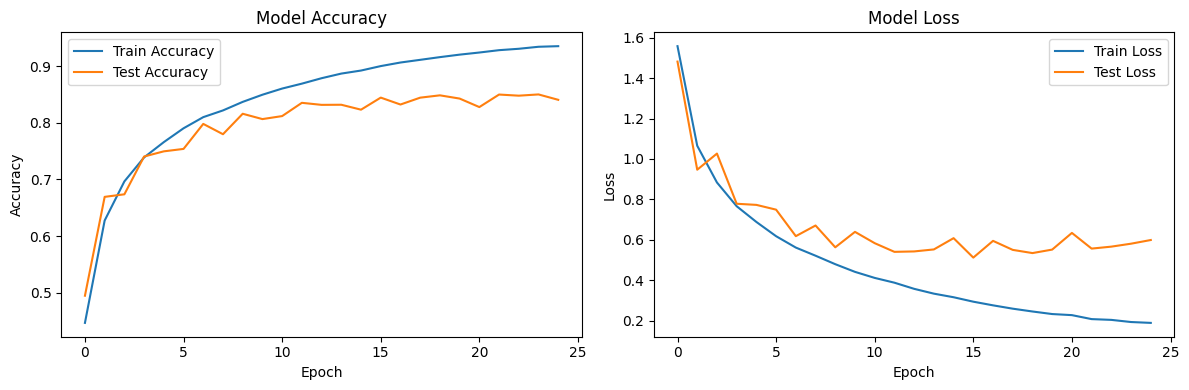

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc * 100:.2f}%")

# Построение графиков обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()